# Wind → Wind-farm · M0 input data · source 03 — asset geometry (boundary polygon + turbine cloud)

**Peril:** Wind · **Layer:** M0 (raw evidence) · *method-neutral — understanding, not the model.*

The **third and final** M0 notebook. `01` met the strong-wind hazard *surface* (ASCE) and `02` the tornado/wind
*record* (SPC). This one meets the **asset** the hazard acts on — the two wind farms, in **two exposure
geometries**, because a wind farm is **spread out** and the two wind sub-perils touch it differently:

- the **boundary polygon** (the lease/site footprint) — the **areal extent** a tornado *path* or a broad wind
  *swath* intersects; and
- the **USWTDB turbine point cloud** — the **per-turbine** locations, because a narrow tornado clips *some*
  turbines and misses the rest (a single centroid point would understate that — AWN-23).

> **Connection note.** The boundary polygon comes from the platform's shared **boundary DB**
> (`renewablesinfo_org/data/dimensions/boundary/powerplants_enriched_v2.parquet`) — the *same source the solar
> sites and `model-gpr` use*, reached via the gitignored `renewablesinfo_org` symlink. Wind *adds* the **USWTDB**
> turbine points (a wind-specific layer the boundary DB doesn't carry). (Currently a local parquet; a Neon DB may
> back it later — the access pattern stays the same.)

> Plan: [`m0_input_data.md`](../../../docs/plans/convective_wind/m0_input_data.md) · Coupling (areal vs per-turbine):
> [`discussion/convective_wind/02`](../../../docs/extra/discussion/convective_wind/02_coupling_buckets_and_wind.md) · Principle:
> [`exploratory_data_notebooks`](../../../docs/principles/notebook_work/exploratory_data_notebooks.md).

## 0 · Intent & scope

**Does:** load each site's **boundary polygon** (areal footprint + area) and its **USWTDB turbine cloud**
(points within the polygon); reconcile the **capacity** views (boundary nameplate vs Σ turbine ratings);
estimate **TIV** ($/kW basis) so every downstream metric can be shown **% of TIV alongside $**; and emit a clean
per-site geometry record + manifest.

**Does NOT:** compute any coupling or loss — the polygon feeds M2 tornado **areal** intersection and the turbine
cloud feeds the **per-turbine** strike view; M3 splits TIV by subsystem. Sources are public, no auth.

## Assumptions (this layer)

- **AWN-12** — two sites (Traverse OK proving / Shepherds Flat OR baseline).
- **AWN-13** — turbine point locations from **USWTDB** (per-turbine view); coverage **confirmed** for both here.
- **AWN-14** — **TIV estimated from a $/kW basis** (no registry TIV); report **% of TIV alongside $** (same
  caveat as hail A19 / wildfire AW-20).
- **AWN-23** — **per-turbine cloud vs areal footprint**: a single point lookup *understates* an areal/linear
  asset's tornado-strike exposure → keep both geometries; M2 uses the polygon for areal extent, the points for
  the refined per-turbine view.

Full register: [`assumptions.md`](../../../docs/plans/convective_wind/assumptions.md).

## 1 · From-scratch — two geometries, two coupling needs

A solar plant is compact; a wind farm sprawls over tens of km with turbines strung across it. So **one geometry
is not enough** — the two wind sub-perils read the asset differently:

| geometry | what it is | source | feeds |
|---|---|---|---|
| **boundary polygon** | the lease/site footprint (an area) | boundary DB (OSM/EIA; the platform's shared connection) | **areal** extent — tornado *path* ∩ farm (M2); the broad wind *swath* (already read pointwise in `01`) |
| **turbine point cloud** | each turbine's lat/lon + rating | **USWTDB** (USGS/LBNL) | the **per-turbine** strike view — a tornado clips *some* turbines (AWN-23) |

The reference is explicit: *"a point lookup understates linear assets — a long line of turbines has many times
the strike exposure of a single point."* So we carry **both**: the polygon for *where the farm is*, the cloud
for *where each turbine is*.

## 2 · The fields + the "a number is meaningless without its base" table

| Field | What it is | Units / reference base | What it is **NOT** | Use |
|---|---|---|---|---|
| boundary `output` | the **farm** nameplate | **kW** (÷1000 = MW) | not a per-turbine value; not TIV | authoritative farm capacity → TIV |
| boundary `geometry` | the lease/site footprint | WKB polygon, WGS84 | not the turbine count; an OSM lease boundary (can be loose) | areal extent (M2) |
| USWTDB `t_cap` | a **single turbine's** rating | **kW** | not the farm total | per-turbine capacity |
| USWTDB `p_cap` | the **project** nameplate | **MW** | may be per-*phase*, not the whole farm | cross-check |
| USWTDB `xlong, ylat` | turbine location | degrees WGS84 | — | per-turbine cloud (M2) |
| TIV | total insured value | **$ = MW × $/kW** (estimated, AWN-14) | not a registry value | the %-of-TIV denominator |

> **Frame rule.** `output`/`p_cap`/`t_cap` are **three different bases** — farm vs project-phase vs single
> turbine. The boundary `output` is the authoritative **farm** nameplate (→ TIV); `t_cap` is **per-turbine**;
> never sum across the wrong one. And the boundary polygon is an **OSM lease boundary** — it can over- or
> under-capture the turbine cloud (we check, §4).

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import geopandas as gpd
from shapely import wkb
from shapely.geometry import Point
import matplotlib.pyplot as plt

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root (AGENTS.md) not found")


ROOT = _repo_root()
DATA_DIR = ROOT / "data" / "convective_wind"
RAW = DATA_DIR / "raw"
RAW.mkdir(parents=True, exist_ok=True)
_UA = {"User-Agent": "infrasure-hazard-modeling/0.1 (M0 research notebook)"}

# The shared boundary DB — the SAME connection the solar sites + model-gpr use (via the gitignored symlink).
BND_PATH = ROOT / "renewablesinfo_org" / "data" / "dimensions" / "boundary" / "powerplants_enriched_v2.parquet"
USWTDB_API = "https://energy.usgs.gov/api/uswtdb/v1/turbines"
TIV_PER_KW = 1400.0          # USD/kW installed (land-based wind, NREL-ATB ballpark) — ESTIMATED placeholder (AWN-14)

ASSETS = [
    {"slug": "traverse_wind_ok", "name_pat": "traverse", "name": "Traverse Wind Energy Center",
     "role": "proving (high-wind)", "state": "OK", "lat": 35.713427, "lon": -98.728532},
    {"slug": "shepherds_flat_or", "name_pat": r"shepherd'?s?\s*flat", "name": "Shepherds Flat",
     "role": "baseline (low-wind)", "state": "OR", "lat": 45.653389, "lon": -120.036724},
]
print(f"repo root: {ROOT}")
print(f"boundary DB present: {BND_PATH.exists()}  (shared connection — solar + model-gpr use the same)")

repo root: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling
boundary DB present: True  (shared connection — solar + model-gpr use the same)


## 3 · Source & provenance (pin it, cache it)

- **Boundary polygon:** `powerplants_enriched_v2.parquet` (renewablesinfo boundary DB; OSM/EIA-derived plant
  polygons) — the platform's shared geometry connection. Geometry is **WKB**; matched by **name** (`eia_id` is
  null for both wind sites, so the wildfire `eia_id` join doesn't apply here).
- **Turbine cloud:** **USWTDB** (US Wind Turbine Database, USGS/LBNL, quarterly) via the public PostgREST API at
  `energy.usgs.gov` (no auth). Queried by **bounding box** (robust to USWTDB's per-*phase* project naming), then
  filtered to turbines **inside the polygon**. Raw pulls cached under `data/convective_wind/raw/` (gitignored).

In [2]:
def load_boundary(a: dict):
    """Return (polygon, farm_nameplate_MW, operator, start_date) from the shared boundary DB, matched by name."""
    bnd = pd.read_parquet(BND_PATH, columns=["name", "source", "output", "operator", "start_date", "geometry"])
    wind = bnd[bnd["source"].astype(str).str.contains("wind", case=False, na=False)]
    hit = wind[wind["name"].astype(str).str.contains(a["name_pat"], case=False, na=False, regex=True)]
    if not len(hit):
        raise RuntimeError(f"{a['slug']}: no boundary match")
    row = hit.iloc[0]
    return (wkb.loads(row["geometry"]), float(row["output"]) / 1000.0, row["operator"], row["start_date"])


def fetch_uswtdb_bbox(a: dict, poly, pad: float = 0.02) -> pd.DataFrame:
    """USWTDB turbines in the polygon's bbox (cached). Cache-first → reused on re-run."""
    cache = RAW / f"uswtdb_{a['slug']}.json"
    if cache.exists():
        return pd.DataFrame(json.loads(cache.read_text()))
    minx, miny, maxx, maxy = poly.bounds
    params = {"xlong": [f"gte.{minx - pad}", f"lte.{maxx + pad}"],
              "ylat": [f"gte.{miny - pad}", f"lte.{maxy + pad}"],
              "select": "case_id,p_name,t_state,t_county,xlong,ylat,t_cap,p_cap,t_model,p_year"}
    r = requests.get(USWTDB_API, params=params, headers=_UA, timeout=90)
    r.raise_for_status()
    cache.write_text(r.text)
    return pd.DataFrame(r.json())

## 4 · Load both geometries + reconcile (the exposure each site actually presents)

In [3]:
for a in ASSETS:
    poly, farm_mw, operator, start = load_boundary(a)
    area_km2 = float(gpd.GeoSeries([poly], crs=4326).to_crs(5070).area.iloc[0]) / 1e6
    tb = fetch_uswtdb_bbox(a, poly)
    inside = tb[[poly.contains(Point(x, y)) for x, y in zip(tb.xlong, tb.ylat)]].copy()
    a.update(poly=poly, farm_mw=farm_mw, operator=operator, start=start, area_km2=area_km2,
             turbines=inside, n_turb=len(inside), turb_mw=inside["t_cap"].sum() / 1000.0)
    comp = inside["p_name"].value_counts().to_dict()
    print(f"\n{a['name']} ({a['state']}) — {a['role']}")
    print(f"  boundary polygon : {poly.geom_type}, {area_km2:.0f} km²; farm nameplate (boundary DB) = {farm_mw:.0f} MW")
    print(f"  turbines IN polygon: {len(inside)}  (Σ t_cap = {a['turb_mw']:.0f} MW); operator {operator}, online {start}")
    print(f"  USWTDB project composition: {comp}")
print("\nraw USWTDB pulls cached under data/convective_wind/raw/ (gitignored).")


Traverse Wind Energy Center (OK) — proving (high-wind)
  boundary polygon : Polygon, 603 km²; farm nameplate (boundary DB) = 999 MW
  turbines IN polygon: 356  (Σ t_cap = 837 MW); operator Invenergy, online 2022-04
  USWTDB project composition: {'Traverse Wind': 299, 'unknown Custer County': 52, 'unknown Blaine County': 5}

Shepherds Flat (OR) — baseline (low-wind)
  boundary polygon : Polygon, 211 km²; farm nameplate (boundary DB) = 845 MW
  turbines IN polygon: 384  (Σ t_cap = 1046 MW); operator Caithness Shepherds Flat LLC, online 2012-02
  USWTDB project composition: {'Horseshoe Bend': 116, 'South Hurlburt': 116, 'Shepherds Flat': 82, 'Willow Creek': 35, 'North Hurlburt': 24, 'Pebble Springs': 11}

raw USWTDB pulls cached under data/convective_wind/raw/ (gitignored).


> **Two honest geometry findings** (the kind a centroid would hide):
> - **Traverse** — the polygon cleanly holds 356 turbines (299 named "Traverse Wind" + 57 unnamed Custer/Blaine
>   County turbines, almost certainly Traverse's); no neighbouring farm bleeds in. Σ t_cap ≈ 837 MW vs the 999 MW
>   nameplate — USWTDB is missing a few / the polygon clips some, but it's the same farm.
> - **Shepherds Flat** — its **four real phases** (Horseshoe Bend, South & North Hurlburt, Shepherds Flat ≈ 338
>   turbines) are all inside, but the OSM lease polygon **over-captures ~46 neighbouring turbines** (Willow
>   Creek, Pebble Springs). So the polygon is a good *areal* footprint but a loose *turbine* selector here — we
>   flag it, and use the **boundary-DB nameplate (845 MW) as the authoritative farm capacity** for TIV (not the
>   inflated in-polygon Σ t_cap).

## 5 · Decode one of each — what a polygon row and a turbine row literally are

In [4]:
T = ASSETS[0]
print(f"ONE boundary polygon — {T['name']}:")
print(f"  type {T['poly'].geom_type} · area {T['area_km2']:.0f} km² · bbox {tuple(round(b,3) for b in T['poly'].bounds)}")
print(f"  → an AREAL footprint (the lease/site), WGS84; NOT the turbine count.")
ex = T["turbines"].iloc[0]
print(f"\nONE turbine (USWTDB) in {T['name']}:")
print(f"  ({ex.ylat:.4f}, {ex.xlong:.4f}) · {ex.t_cap:.0f} kW · model {ex.t_model} · project '{ex.p_name}' · yr {ex.get('p_year')}")
print(f"  → a POINT with a PER-TURBINE rating ({ex.t_cap:.0f} kW); {T['n_turb']} of these make the farm's cloud.")

ONE boundary polygon — Traverse Wind Energy Center:
  type Polygon · area 603 km² · bbox (-98.904, 35.55, -98.458, 35.838)
  → an AREAL footprint (the lease/site), WGS84; NOT the turbine count.

ONE turbine (USWTDB) in Traverse Wind Energy Center:
  (35.7273, -98.8402) · 2800 kW · model GE2.8-127 · project 'Traverse Wind' · yr 2022.0
  → a POINT with a PER-TURBINE rating (2800 kW); 356 of these make the farm's cloud.


## 6 · Field dictionary — complete pass (boundary + USWTDB), with caveats

In [5]:
fields = pd.DataFrame([
    ("boundary.name", "plant name", "string", "YES — match key (eia_id is null here)"),
    ("boundary.source", "fuel type", "string ('wind')", "YES — filter to wind"),
    ("boundary.output", "FARM nameplate", "kW (÷1000=MW)", "YES — authoritative capacity → TIV"),
    ("boundary.geometry", "lease/site footprint", "WKB polygon, WGS84", "YES — areal extent (M2); OSM lease (can be loose)"),
    ("boundary.operator / start_date", "owner / online date", "string", "context"),
    ("boundary.eia_id", "EIA cross-link", "string", "⚠ NULL for both wind sites — cannot EIA-join here"),
    ("uswtdb.xlong / ylat", "turbine location", "deg WGS84", "YES — per-turbine cloud (M2)"),
    ("uswtdb.t_cap", "single-turbine rating", "kW", "YES — per-turbine capacity"),
    ("uswtdb.t_model", "turbine model", "string", "context (M3 fragility anchor)"),
    ("uswtdb.p_name", "project name", "string", "YES — composition check; ⚠ DIFFERS from boundary name; per-phase"),
    ("uswtdb.p_cap", "project nameplate", "MW", "cross-check; ⚠ may be per-phase, not the whole farm"),
], columns=["field", "what it is", "units / base", "use"])
print("complete pass — boundary DB + USWTDB fields (no undocumented):")
print(fields.to_string(index=False))
print("\nCaveats carried forward: (1) eia_id null → name-match only; (2) USWTDB project names differ from the")
print("boundary name and are split per-phase → match spatially (point-in-polygon), not by name; (3) the OSM")
print("polygon over-captures neighbours at Shepherds Flat → use boundary nameplate for TIV, polygon for areal extent.")

complete pass — boundary DB + USWTDB fields (no undocumented):
                         field            what it is       units / base                                                              use
                 boundary.name            plant name             string                            YES — match key (eia_id is null here)
               boundary.source             fuel type    string ('wind')                                             YES — filter to wind
               boundary.output        FARM nameplate      kW (÷1000=MW)                               YES — authoritative capacity → TIV
             boundary.geometry  lease/site footprint WKB polygon, WGS84                YES — areal extent (M2); OSM lease (can be loose)
boundary.operator / start_date   owner / online date             string                                                          context
               boundary.eia_id        EIA cross-link             string                ⚠ NULL for both wind sites —

## 7 · Capacity & TIV (the %-of-TIV denominator, AWN-14)

In [6]:
rows = []
for a in ASSETS:
    tiv = a["farm_mw"] * 1000.0 * TIV_PER_KW
    rows.append({"site": a["slug"], "role": a["role"],
                 "farm_nameplate_MW": round(a["farm_mw"], 0),
                 "turbines_in_polygon": a["n_turb"],
                 "Σ turbine t_cap_MW": round(a["turb_mw"], 0),
                 "TIV_$M (est)": round(tiv / 1e6, 0)})
    a["tiv"] = tiv
tiv_tab = pd.DataFrame(rows)
print(f"TIV basis: ${TIV_PER_KW:,.0f}/kW installed (land-based wind, NREL-ATB ballpark) — ESTIMATED (AWN-14).")
print(tiv_tab.to_string(index=False))
print("\n→ TIV uses the boundary-DB FARM nameplate (authoritative), not the in-polygon Σ t_cap (which over-counts at")
print("  Shepherds Flat). Subsystem cost-split (rotor/nacelle/tower/...) is deferred to M3; every M4 metric will be")
print("  shown as % of TIV alongside dollars. TIV here is a placeholder $/kW — refine with a registry/valuation basis.")

TIV basis: $1,400/kW installed (land-based wind, NREL-ATB ballpark) — ESTIMATED (AWN-14).
             site                role  farm_nameplate_MW  turbines_in_polygon  Σ turbine t_cap_MW  TIV_$M (est)
 traverse_wind_ok proving (high-wind)              999.0                  356               837.0        1399.0
shepherds_flat_or baseline (low-wind)              845.0                  384              1046.0        1183.0

→ TIV uses the boundary-DB FARM nameplate (authoritative), not the in-polygon Σ t_cap (which over-counts at
  Shepherds Flat). Subsystem cost-split (rotor/nacelle/tower/...) is deferred to M3; every M4 metric will be
  shown as % of TIV alongside dollars. TIV here is a placeholder $/kW — refine with a registry/valuation basis.


## 8 · The map — boundary polygon + turbine cloud (the spread that makes the per-turbine view matter)

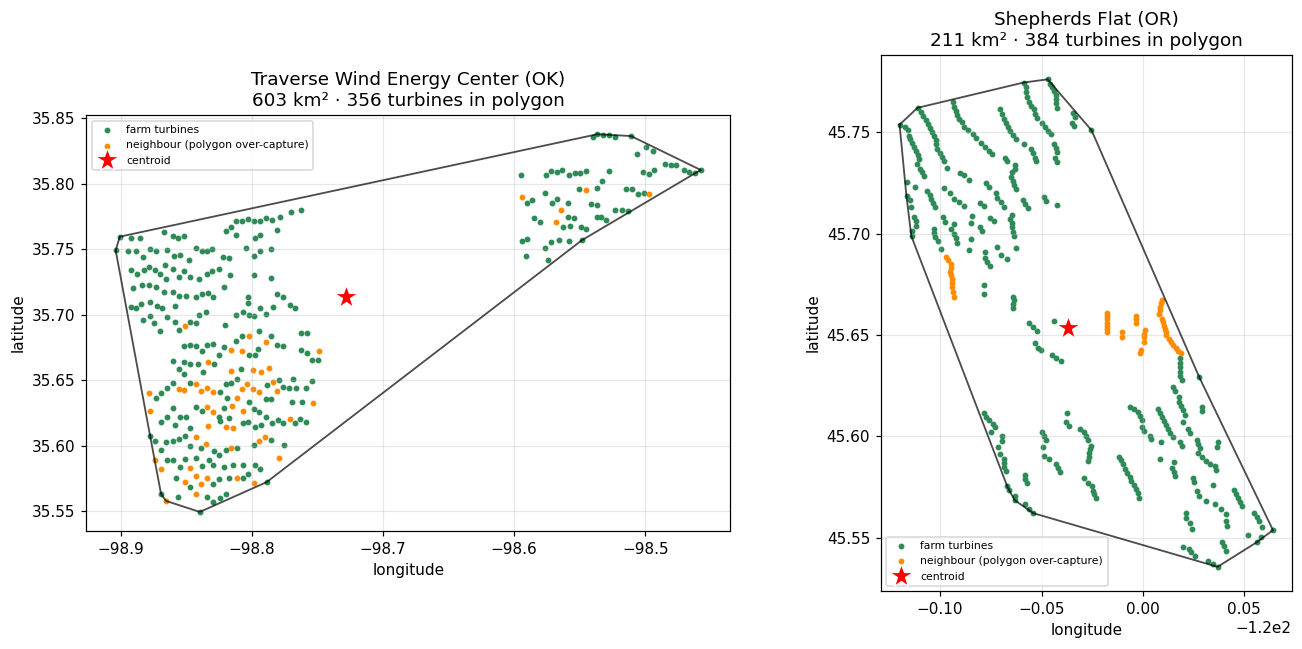

Takeaway: each farm is a CLOUD of turbines spread across tens of km, not a point — a single centroid (red ★)
would badly understate a tornado's per-turbine strike exposure (AWN-23). The polygon gives the areal extent
a tornado PATH intersects (M2 areal); the green points give the per-turbine resolution within it. (Shepherds
Flat: orange = neighbouring turbines the loose OSM polygon over-captures — flagged, excluded from TIV.)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, a in zip(axes, ASSETS):
    poly = a["poly"]
    geoms = poly.geoms if poly.geom_type == "MultiPolygon" else [poly]
    for g in geoms:
        x, y = g.exterior.xy
        ax.plot(x, y, "k-", lw=1.2, alpha=0.7)
    tb = a["turbines"]
    # colour by whether the turbine's project name matches the farm (vs a neighbour the polygon over-captured)
    core = tb["p_name"].astype(str).str.contains(a["name_pat"].split("'")[0].split("\\")[0], case=False, na=False) | \
        tb["p_name"].astype(str).str.contains("hurlburt|horseshoe", case=False, na=False, regex=True)
    ax.scatter(tb.loc[core, "xlong"], tb.loc[core, "ylat"], s=8, c="seagreen", label="farm turbines")
    if (~core).any():
        ax.scatter(tb.loc[~core, "xlong"], tb.loc[~core, "ylat"], s=8, c="darkorange", label="neighbour (polygon over-capture)")
    ax.plot(a["lon"], a["lat"], "r*", ms=16, mec="white", mew=0.8, zorder=5, label="centroid")
    ax.set_title(f"{a['name']} ({a['state']})\n{a['area_km2']:.0f} km² · {a['n_turb']} turbines in polygon")
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude"); ax.set_aspect("equal", "box"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()
print("Takeaway: each farm is a CLOUD of turbines spread across tens of km, not a point — a single centroid (red ★)")
print("would badly understate a tornado's per-turbine strike exposure (AWN-23). The polygon gives the areal extent")
print("a tornado PATH intersects (M2 areal); the green points give the per-turbine resolution within it. (Shepherds")
print("Flat: orange = neighbouring turbines the loose OSM polygon over-captures — flagged, excluded from TIV.)")

## 9 · Emit per-site geometry records + manifests

In [8]:
for a in ASSETS:
    tb = a["turbines"][["xlong", "ylat", "t_cap", "t_model", "p_name", "p_year"]].copy()
    tb = tb.rename(columns={"xlong": "lon", "ylat": "lat", "t_cap": "t_cap_kw"})
    tb.insert(0, "asset", a["slug"])
    out_pq = DATA_DIR / f"{a['slug']}_wind_m0_geometry.parquet"
    tb.to_parquet(out_pq, index=False)

    manifest = {
        "layer": "M0", "source": "03_asset_geometry", "peril": "wind",
        "asset": {k: a[k] for k in ("slug", "name", "role", "state", "lat", "lon")},
        "boundary": {
            "source": "renewablesinfo boundary DB (OSM/EIA) powerplants_enriched_v2.parquet — shared connection",
            "geom_type": a["poly"].geom_type, "area_km2": round(a["area_km2"], 1),
            "farm_nameplate_mw": round(a["farm_mw"], 1), "operator": a["operator"], "online": str(a["start"]),
            "polygon_wkt": a["poly"].wkt,           # portable copy of the footprint (no symlink dependency for M2)
        },
        "turbines": {
            "source": "USWTDB (USGS/LBNL) energy.usgs.gov API — bbox query → point-in-polygon",
            "n_in_polygon": a["n_turb"], "sum_t_cap_mw": round(a["turb_mw"], 1),
            "project_composition": {str(k): int(v) for k, v in a["turbines"]["p_name"].value_counts().items()},
            "models": {str(k): int(v) for k, v in a["turbines"]["t_model"].value_counts().items()},
        },
        "tiv": {"basis_usd_per_kw": TIV_PER_KW, "tiv_usd": round(a["tiv"], 0),
                "status": "ESTIMATED (AWN-14) — refine with registry/valuation; show % of TIV alongside $"},
        "caveats": [
            "eia_id null for both → matched by name, not EIA join",
            "USWTDB project names differ + per-phase → spatial (point-in-polygon) match, not name match",
            "Shepherds Flat OSM polygon over-captures ~46 neighbour turbines (Willow Creek, Pebble Springs)",
            "TIV uses boundary-DB farm nameplate (authoritative), not in-polygon Σ t_cap",
        ],
        "feeds": {"M2_areal": "boundary polygon ∩ tornado path", "M2_per_turbine": "turbine cloud strike view",
                  "M3": "subsystem TIV split", "M4": "% of TIV denominator"},
    }
    (DATA_DIR / f"{a['slug']}_wind_m0_geometry_manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
    print(f"wrote {out_pq.relative_to(ROOT)} ({a['n_turb']} turbines) + manifest  "
          f"[{a['area_km2']:.0f} km², {a['farm_mw']:.0f} MW, TIV ${a['tiv']/1e6:.0f}M est]")

wrote data/convective_wind/traverse_wind_ok_wind_m0_geometry.parquet (356 turbines) + manifest  [603 km², 999 MW, TIV $1399M est]
wrote data/convective_wind/shepherds_flat_or_wind_m0_geometry.parquet (384 turbines) + manifest  [211 km², 845 MW, TIV $1183M est]


### Findings & open questions (→ M2) — and M0 is now complete

**What the geometry says.**
- Each farm is an **areal, multi-turbine asset**: Traverse ≈ **356 turbines over ~600 km²**, Shepherds Flat ≈
  **338 (its 4 phases) over ~210 km²** — a *cloud*, not a point (AWN-23). Two geometries kept: the **polygon**
  (areal extent) and the **turbine cloud** (per-turbine resolution).
- **TIV (estimated):** Traverse ≈ **$1.4 B**, Shepherds Flat ≈ **$1.2 B** at $1,400/kW (AWN-14, placeholder) —
  the denominator for every %-of-TIV metric.
- Honest geometry caveats surfaced (loose OSM polygon at Shepherds Flat; USWTDB per-phase naming; null eia_id).

**Open → next phases.**
- **(M2 areal)** intersect the **boundary polygon** with tornado **paths** (path-aware Minkowski, `02` path stats).
- **(M2 per-turbine)** the **turbine cloud** gives the refined strike view — a tornado clips *some* turbines; the
  per-turbine-vs-point distinction (AWN-23) earns its keep here.
- **(M3)** split TIV by subsystem; the turbine **model** (GE 2.8-127 / GE 2.75-127) anchors the fragility curve.
- **(M0)** refine the TIV $/kW with a registry/valuation basis.

**M0 is complete** — the wind hazard is now *understood across all three shapes*: the **ASCE pre-integrated
surface** (`01`, strong wind), the **bias-audited SPC record** (`02`, tornado + convective wind), and the
**asset geometry** (`03`, the two farms). → **M1**: per-sub-peril catalog — strong wind = profile-assembly off
the ASCE surface (no λ-fit); tornado = bias-corrected SPC fit (λ + bounded-GPD/EF severity), the polygon + cloud
carried into M2 coupling.